# Assignment 02: Intelligent Tools for Software Evolution

This notebook reproduces the coursework analysis using the AIDev-pop/AIDev dataset. It is organized around the required research questions and exports tables/figures for the report.

## 1. Setup

Import libraries, configure paths, and create output directories. Run this notebook from the `notebooks/` directory or from Jupyter with this file open.

In [ ]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportion_confint

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_RAW = PROJECT_ROOT / 'data' / 'raw'
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
FIGURES = PROJECT_ROOT / 'figures'
SCRIPTS = PROJECT_ROOT / 'scripts'

for directory in [DATA_RAW, DATA_PROCESSED, FIGURES]:
    directory.mkdir(parents=True, exist_ok=True)

if str(SCRIPTS) not in sys.path:
    sys.path.insert(0, str(SCRIPTS))

sns.set_theme(style='whitegrid')
print(PROJECT_ROOT)

: 

## 2. Dataset Availability

The raw files should exist in `data/raw/`. If they are missing, run the download script from a terminal:

```text
.venv/bin/python scripts/download_data.py
```

The notebook checks the expected files before continuing.

In [2]:
required_raw_files = [
    'pull_request.parquet',
    'repository.parquet',
    'pr_reviews.parquet',
    'pr_comments.parquet',
    'pr_commit_details.parquet',
    'pr_task_type.parquet',
    'related_issue.parquet',
]

missing = [name for name in required_raw_files if not (DATA_RAW / name).exists()]
if missing:
    raise FileNotFoundError(f'Missing raw dataset files: {missing}. Run scripts/download_data.py first.')

pd.DataFrame({
    'file': required_raw_files,
    'size_mb': [round((DATA_RAW / name).stat().st_size / 1024 / 1024, 2) for name in required_raw_files],
})

,file,size_mb
0,pull_request.parquet,16.07
1,repository.parquet,0.16
2,pr_reviews.parquet,7.17
3,pr_comments.parquet,24.66
4,pr_commit_details.parquet,462.74
5,pr_task_type.parquet,2.85
6,related_issue.parquet,0.07


## 3. Prepare One-Row-Per-PR Analysis Table

This cell uses the same preparation functions as `scripts/prepare_data.py` and creates `data/processed/pr_analysis.parquet`. The table contains PR acceptance, timing variables, repository metadata, task type, review/comment counts, file-change metrics, and file-category flags.

In [3]:
from prepare_data import main as prepare_analysis_data

prepare_analysis_data()
analysis_path = DATA_PROCESSED / 'pr_analysis.parquet'
df = pd.read_parquet(analysis_path)

print(df.shape)
df[['pr_id', 'agent', 'state', 'is_closed', 'is_merged', 'created_at', 'merged_at', 'stars', 'forks', 'files_changed', 'churn']].head()

/Users/moutaz/Documents/projects/SW-projects/agent-pr-analyzer/scripts/prepare_data.py:127: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["is_issue_linked"] = df["is_issue_linked"].fillna(False)
/Users/moutaz/Documents/projects/SW-projects/agent-pr-analyzer/scripts/prepare_data.py:131: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[column] = df[column].fillna(False)


Wrote 33,596 PR rows to /Users/moutaz/Documents/projects/SW-projects/agent-pr-analyzer/data/processed/pr_analysis.parquet
agent
OpenAI_Codex    21799
Copilot          4970
Devin            4827
Cursor           1541
Claude_Code       459
(33596, 58)


,pr_id,agent,state,is_closed,is_merged,created_at,merged_at,stars,forks,files_changed,churn
0,3264933329,Claude_Code,closed,True,False,2025-07-26 02:59:01+00:00,NaT,1230,368,3.0,396.0
1,3265118634,Claude_Code,closed,True,True,2025-07-26 04:56:55+00:00,2025-07-26 22:12:24+00:00,391,21,11.0,76.0
2,3265640341,Claude_Code,closed,True,True,2025-07-26 13:31:19+00:00,2025-07-26 13:37:22+00:00,505,19,5.0,407.0
3,3265709660,Claude_Code,closed,True,True,2025-07-26 14:07:22+00:00,2025-07-26 14:45:30+00:00,367,90,15.0,300.0
4,3265782173,Claude_Code,open,False,False,2025-07-26 15:02:48+00:00,NaT,4835,1746,21.0,221.0


## 4. Dataset Overview

Before answering the research questions, inspect the number of PRs, agents, closed PRs, merged PRs, and the time period covered.

In [4]:
overview = {
    'total_prs': len(df),
    'closed_prs': int(df['is_closed'].sum()),
    'merged_prs': int(df['is_merged'].sum()),
    'agents': int(df['agent'].nunique()),
    'repositories': int(df['repo_id'].nunique()),
    'created_from': df['created_at'].min(),
    'created_to': df['created_at'].max(),
}
overview

{'total_prs': 33596,
 'closed_prs': 31284,
 'merged_prs': 24014,
 'agents': 5,
 'repositories': 2807,
 'created_from': Timestamp('2024-12-24 00:23:09+0000', tz='UTC'),
 'created_to': Timestamp('2025-07-30 19:36:13+0000', tz='UTC')}

In [5]:
df['agent'].value_counts().rename_axis('agent').reset_index(name='prs')

,agent,prs
0,OpenAI_Codex,21799
1,Copilot,4970
2,Devin,4827
3,Cursor,1541
4,Claude_Code,459


## 5. RQ1: Do AI Coding Agents Differ in Pull Request Acceptance Rates?

Acceptance is defined as `merged_at` being present. The acceptance rate is calculated among closed PRs:

\[
Acceptance\ Rate = 
rac{Merged\ PRs}{Closed\ PRs}
\]

This avoids treating still-open PRs as rejected.

In [6]:
rq1 = (
    df.groupby('agent')
    .agg(
        total_prs=('pr_id', 'count'),
        closed_prs=('is_closed', 'sum'),
        merged_prs=('is_merged', 'sum'),
    )
    .reset_index()
)
rq1['acceptance_rate'] = rq1['merged_prs'] / rq1['closed_prs']

ci = rq1.apply(
    lambda row: proportion_confint(
        count=row['merged_prs'],
        nobs=row['closed_prs'],
        alpha=0.05,
        method='wilson',
    ),
    axis=1,
)
rq1['acceptance_ci_low'] = [item[0] for item in ci]
rq1['acceptance_ci_high'] = [item[1] for item in ci]
rq1 = rq1.sort_values('acceptance_rate', ascending=False)

rq1_path = DATA_PROCESSED / 'rq1_acceptance_by_agent.csv'
rq1.to_csv(rq1_path, index=False)
rq1

,agent,total_prs,closed_prs,merged_prs,acceptance_rate,acceptance_ci_low,acceptance_ci_high
4,OpenAI_Codex,21799,20993,18004,0.857619,0.852827,0.862281
2,Cursor,1541,1347,1005,0.746102,0.722182,0.768623
0,Claude_Code,459,380,271,0.713158,0.665728,0.756322
3,Devin,4827,4673,2595,0.555318,0.541030,0.569514
1,Copilot,4970,3891,2139,0.549730,0.534056,0.565306


In [7]:
contingency = rq1[['agent', 'merged_prs', 'closed_prs']].copy()
contingency['not_merged_closed_prs'] = contingency['closed_prs'] - contingency['merged_prs']

chi2, p_value, dof, expected = chi2_contingency(contingency[['merged_prs', 'not_merged_closed_prs']])

rq1_test = pd.DataFrame({
    'test': ['chi-square test of independence'],
    'chi2': [chi2],
    'dof': [dof],
    'p_value': [p_value],
})
rq1_test

,test,chi2,dof,p_value
0,chi-square test of independence,3179.347395,4,0.0


PosixPath('/Users/moutaz/Documents/projects/SW-projects/agent-pr-analyzer/figures/rq1_acceptance_by_agent.png')

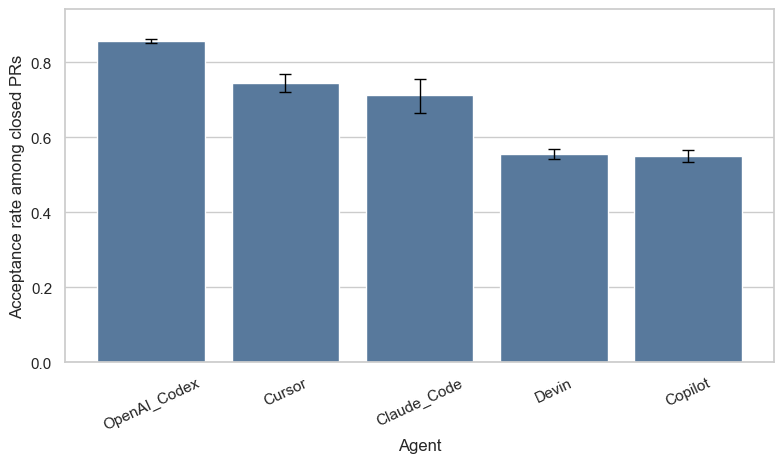

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.8))
sns.barplot(data=rq1, x='agent', y='acceptance_rate', color='#4C78A8', ax=ax)

yerr_low = rq1['acceptance_rate'] - rq1['acceptance_ci_low']
yerr_high = rq1['acceptance_ci_high'] - rq1['acceptance_rate']
ax.errorbar(
    x=range(len(rq1)),
    y=rq1['acceptance_rate'],
    yerr=[yerr_low, yerr_high],
    fmt='none',
    color='black',
    capsize=4,
    linewidth=1,
)

ax.set_xlabel('Agent')
ax.set_ylabel('Acceptance rate among closed PRs')
ax.set_ylim(0, min(1.0, rq1['acceptance_ci_high'].max() + 0.08))
ax.tick_params(axis='x', rotation=25)
fig.tight_layout()

rq1_figure_path = FIGURES / 'rq1_acceptance_by_agent.png'
fig.savefig(rq1_figure_path, dpi=200)
rq1_figure_path

### RQ1 Interpretation Draft

Acceptance rates differ by agent, and the chi-square test indicates a significant association between agent and merge outcome. Interpret this carefully because repository and task context may also influence acceptance.

## 6. RQ2: Do AI Coding Agents Differ in Review Turnaround Time?

For review turnaround, this notebook uses **time from PR creation to first human response**. The first human response is the earliest timestamp among:

- first non-bot PR review
- first non-bot PR comment

This metric is broader than review-only turnaround and better captures when maintainers first engage with an AI-generated PR. PRs without a human review/comment are excluded from this RQ2 timing comparison.

In [9]:
rq2_metric = 'time_to_first_human_response_hours'
rq2_df = df[df[rq2_metric].notna() & (df[rq2_metric] >= 0)].copy()
rq2_df['time_to_first_human_response_days'] = rq2_df[rq2_metric] / 24

rq2 = (
    rq2_df.groupby('agent')
    .agg(
        total_prs=('pr_id', 'count'),
        median_hours=(rq2_metric, 'median'),
        mean_hours=(rq2_metric, 'mean'),
        q1_hours=(rq2_metric, lambda s: s.quantile(0.25)),
        q3_hours=(rq2_metric, lambda s: s.quantile(0.75)),
    )
    .reset_index()
)
rq2['median_days'] = rq2['median_hours'] / 24
nrq2 = rq2.sort_values('median_hours')

rq2_path = DATA_PROCESSED / 'rq2_turnaround_by_agent.csv'
rq2.to_csv(rq2_path, index=False)
rq2.sort_values('median_hours')

,agent,total_prs,median_hours,mean_hours,q1_hours,q3_hours,median_days
3,Devin,2457,0.531389,29.658400,0.068611,8.430556,0.022141
4,OpenAI_Codex,1952,0.575833,41.071815,0.038264,13.005347,0.023993
1,Copilot,3435,0.760000,23.904228,0.314028,4.988194,0.031667
2,Cursor,576,0.850694,32.252624,0.032778,15.485694,0.035446
0,Claude_Code,221,1.087222,50.663697,0.088889,13.948889,0.045301


In [10]:
from scipy.stats import kruskal

rq2_groups = [group[rq2_metric].values for _, group in rq2_df.groupby('agent')]
kruskal_stat, kruskal_p = kruskal(*rq2_groups)

rq2_test = pd.DataFrame({
    'test': ['Kruskal-Wallis H-test'],
    'metric': [rq2_metric],
    'statistic': [kruskal_stat],
    'p_value': [kruskal_p],
    'groups': [rq2_df['agent'].nunique()],
    'observations': [len(rq2_df)],
})
rq2_test

,test,metric,statistic,p_value,groups,observations
0,Kruskal-Wallis H-test,time_to_first_human_response_hours,89.702215,1.523216e-18,5,8641


PosixPath('/Users/moutaz/Documents/projects/SW-projects/agent-pr-analyzer/figures/rq2_turnaround_by_agent.png')

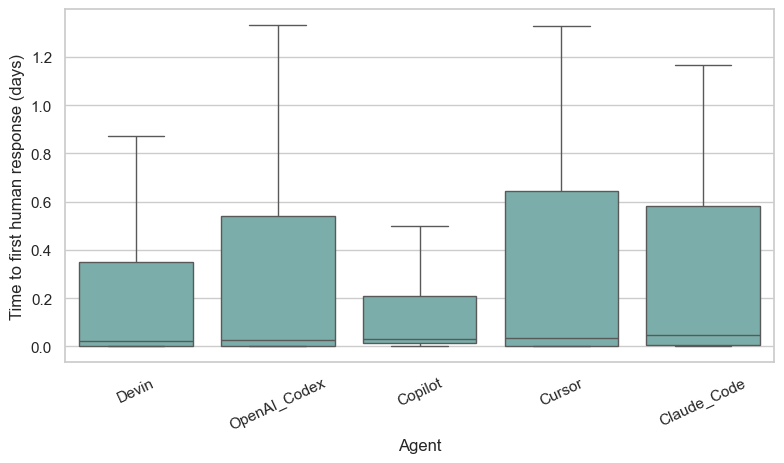

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.8))
plot_order = rq2.sort_values('median_hours')['agent']

sns.boxplot(
    data=rq2_df,
    x='agent',
    y='time_to_first_human_response_days',
    order=plot_order,
    showfliers=False,
    color='#72B7B2',
    ax=ax,
)

ax.set_xlabel('Agent')
ax.set_ylabel('Time to first human response (days)')
ax.tick_params(axis='x', rotation=25)
fig.tight_layout()

rq2_figure_path = FIGURES / 'rq2_turnaround_by_agent.png'
fig.savefig(rq2_figure_path, dpi=200)
rq2_figure_path

### RQ2 Interpretation Draft

Median time to first human response differs across agents. The Kruskal-Wallis test indicates that turnaround-time distributions are not the same, but this analysis only includes PRs with an observed human response.

## 7. Next Sections

The following sections will be added next:

- RQ3: Repository/project factors associated with acceptance
- RQ4-B: Core source-code changes vs peripheral artifact changes

## 7. RQ3: What Repository/Project Factors Are Associated With Acceptance?

For RQ3, acceptance is modeled using logistic regression on **closed PRs only**. The dependent variable is whether the PR was merged.

The model includes agent identity plus project/change-level controls:

- repository popularity: stars and forks
- repository language group
- PR size/change size: files changed, commit count, churn
- review/discussion activity: review count and comment count
- repository AI PR volume
- task type
- touched-file categories: core source, tests, documentation, build/configuration, CI/CD
- issue-linked status

Continuous skewed variables are transformed with `log1p` so large repositories or very large PRs do not dominate the scale.

In [12]:
import statsmodels.formula.api as smf

rq3_df = df[df['is_closed']].copy()
rq3_df['accepted'] = rq3_df['is_merged'].astype(int)

rq3_df['language_group'] = rq3_df['language'].fillna('Unknown')
top_languages = rq3_df['language_group'].value_counts().head(8).index
rq3_df.loc[~rq3_df['language_group'].isin(top_languages), 'language_group'] = 'Other'

for column in [
    'touches_core_source',
    'touches_tests',
    'touches_documentation',
    'touches_build_config',
    'touches_ci_cd',
    'is_issue_linked',
]:
    rq3_df[column] = rq3_df[column].astype(int)

rq3_df['log1p_review_count'] = np.log1p(rq3_df['review_count'])
rq3_df['log1p_comment_count'] = np.log1p(rq3_df['comment_count'])

rq3_model_formula = """
accepted ~ C(agent)
    + log1p_stars
    + log1p_forks
    + C(language_group)
    + log1p_files_changed
    + log1p_commit_count
    + log1p_churn
    + log1p_review_count
    + log1p_comment_count
    + log1p_repo_ai_pr_volume
    + C(task_type)
    + touches_core_source
    + touches_tests
    + touches_documentation
    + touches_build_config
    + touches_ci_cd
    + is_issue_linked
"""

rq3_model = smf.logit(rq3_model_formula, data=rq3_df).fit(disp=False, maxiter=100)

rq3_model_info = pd.DataFrame({
    'observations': [int(rq3_model.nobs)],
    'df_model': [int(rq3_model.df_model)],
    'pseudo_r2_mcfadden': [rq3_model.prsquared],
    'log_likelihood': [rq3_model.llf],
    'llr_p_value': [rq3_model.llr_pvalue],
})
rq3_model_info

,observations,df_model,pseudo_r2_mcfadden,log_likelihood,llr_p_value
0,31284,37,0.2297,-13064.647126,0.0


In [13]:
params = rq3_model.params
conf = rq3_model.conf_int()
summary = pd.DataFrame({
    'term': params.index,
    'coef': params.values,
    'std_error': rq3_model.bse.values,
    'z': rq3_model.tvalues.values,
    'p_value': rq3_model.pvalues.values,
    'odds_ratio': np.exp(params.values),
    'odds_ratio_ci_low': np.exp(conf[0].values),
    'odds_ratio_ci_high': np.exp(conf[1].values),
})
summary = summary.sort_values('p_value')

rq3_path = DATA_PROCESSED / 'rq3_logistic_regression_odds_ratios.csv'
summary.to_csv(rq3_path, index=False)
summary.head(20)

,term,coef,std_error,z,p_value,odds_ratio,odds_ratio_ci_low,odds_ratio_ci_high
29,log1p_review_count,2.041446,0.049585,41.170697,0.000000e+00,7.701738,6.988468,8.487807
31,log1p_repo_ai_pr_volume,0.239568,0.009001,26.614967,4.555596e-156,1.270700,1.248479,1.293317
30,log1p_comment_count,-0.569586,0.045112,-12.626051,1.517025e-36,0.565760,0.517884,0.618061
1,C(agent)[T.Copilot],-1.723402,0.139705,-12.336001,5.796423e-35,0.178458,0.135712,0.234668
3,C(agent)[T.Devin],-1.538667,0.132938,-11.574323,5.560844e-31,0.214667,0.165428,0.278562
0,Intercept,2.260317,0.208415,10.845258,2.100435e-27,9.586131,6.371475,14.422707
28,log1p_churn,-0.127942,0.012014,-10.649800,1.747402e-26,0.879905,0.859428,0.900869
25,log1p_forks,-0.227812,0.022481,-10.133346,3.929667e-24,0.796274,0.761950,0.832145
10,C(language_group)[T.Python],0.547376,0.074494,7.347899,2.013466e-13,1.728710,1.493870,2.000469
6,C(language_group)[T.HTML],1.064819,0.146195,7.283536,3.251819e-13,2.900315,2.177727,3.862664


PosixPath('/Users/moutaz/Documents/projects/SW-projects/agent-pr-analyzer/figures/rq3_logistic_regression_odds_ratios.png')

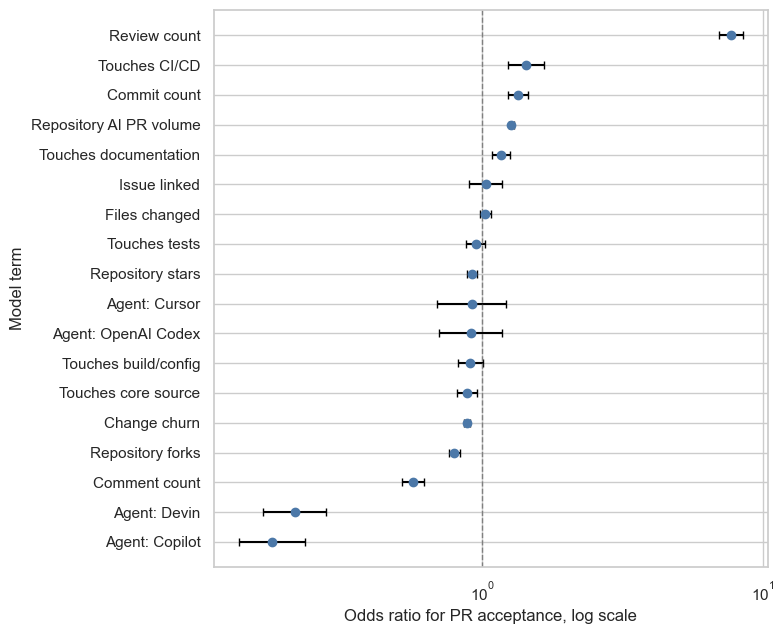

In [14]:
key_terms = [
    'C(agent)[T.Copilot]',
    'C(agent)[T.Cursor]',
    'C(agent)[T.Devin]',
    'C(agent)[T.OpenAI_Codex]',
    'log1p_stars',
    'log1p_forks',
    'log1p_files_changed',
    'log1p_commit_count',
    'log1p_churn',
    'log1p_review_count',
    'log1p_comment_count',
    'log1p_repo_ai_pr_volume',
    'touches_core_source',
    'touches_tests',
    'touches_documentation',
    'touches_build_config',
    'touches_ci_cd',
    'is_issue_linked',
]

plot_terms = summary[summary['term'].isin(key_terms)].copy()
plot_terms['label'] = plot_terms['term'].replace({
    'C(agent)[T.Copilot]': 'Agent: Copilot',
    'C(agent)[T.Cursor]': 'Agent: Cursor',
    'C(agent)[T.Devin]': 'Agent: Devin',
    'C(agent)[T.OpenAI_Codex]': 'Agent: OpenAI Codex',
    'log1p_stars': 'Repository stars',
    'log1p_forks': 'Repository forks',
    'log1p_files_changed': 'Files changed',
    'log1p_commit_count': 'Commit count',
    'log1p_churn': 'Change churn',
    'log1p_review_count': 'Review count',
    'log1p_comment_count': 'Comment count',
    'log1p_repo_ai_pr_volume': 'Repository AI PR volume',
    'touches_core_source': 'Touches core source',
    'touches_tests': 'Touches tests',
    'touches_documentation': 'Touches documentation',
    'touches_build_config': 'Touches build/config',
    'touches_ci_cd': 'Touches CI/CD',
    'is_issue_linked': 'Issue linked',
})
plot_terms = plot_terms.sort_values('odds_ratio')

fig, ax = plt.subplots(figsize=(8, 6.5))
ax.errorbar(
    x=plot_terms['odds_ratio'],
    y=plot_terms['label'],
    xerr=[
        plot_terms['odds_ratio'] - plot_terms['odds_ratio_ci_low'],
        plot_terms['odds_ratio_ci_high'] - plot_terms['odds_ratio'],
    ],
    fmt='o',
    color='#4C78A8',
    ecolor='black',
    capsize=3,
)
ax.axvline(1, color='gray', linestyle='--', linewidth=1)
ax.set_xscale('log')
ax.set_xlabel('Odds ratio for PR acceptance, log scale')
ax.set_ylabel('Model term')
fig.tight_layout()

rq3_figure_path = FIGURES / 'rq3_logistic_regression_odds_ratios.png'
fig.savefig(rq3_figure_path, dpi=200)
rq3_figure_path

### RQ3 Interpretation Draft

The regression suggests that acceptance is associated with agent identity, review activity, repository context, and change size. These are associations, not causal effects, because task assignment and repository practices may differ across agents.

## 8. RQ4-B: Are Peripheral Artifact Changes Accepted More Than Core Source-Code Changes?

For the additional task, changed files are classified into categories such as core source, tests, documentation, build/configuration, CI/CD, dependencies, infrastructure, and other. This section compares acceptance for PRs that touch core source code against PRs that do not touch core source code.

The main comparison is:

- **Touches core source**: at least one changed file is categorized as core source code.
- **Peripheral/no core source**: no changed file is categorized as core source code.

The analysis also reports acceptance by individual file category and by agent/scope combination.

In [15]:
from scipy.stats import chi2_contingency

rq4_df = df[df['is_closed']].copy()
rq4_df['change_scope'] = np.where(
    rq4_df['touches_core_source'],
    'Touches core source',
    'Peripheral/no core source',
)

rq4_scope = (
    rq4_df.groupby('change_scope')
    .agg(
        closed_prs=('pr_id', 'count'),
        merged_prs=('is_merged', 'sum'),
    )
    .reset_index()
)
rq4_scope['acceptance_rate'] = rq4_scope['merged_prs'] / rq4_scope['closed_prs']

ci = rq4_scope.apply(
    lambda row: proportion_confint(
        count=row['merged_prs'],
        nobs=row['closed_prs'],
        alpha=0.05,
        method='wilson',
    ),
    axis=1,
)
rq4_scope['acceptance_ci_low'] = [item[0] for item in ci]
rq4_scope['acceptance_ci_high'] = [item[1] for item in ci]

rq4_scope_path = DATA_PROCESSED / 'rq4b_acceptance_by_scope.csv'
rq4_scope.to_csv(rq4_scope_path, index=False)
rq4_scope

,change_scope,closed_prs,merged_prs,acceptance_rate,acceptance_ci_low,acceptance_ci_high
0,Peripheral/no core source,9889,7958,0.804733,0.796802,0.812426
1,Touches core source,21395,16056,0.750456,0.744612,0.756209


In [16]:
rq4_contingency = rq4_scope[['change_scope', 'merged_prs', 'closed_prs']].copy()
rq4_contingency['not_merged_closed_prs'] = rq4_contingency['closed_prs'] - rq4_contingency['merged_prs']
rq4_chi2, rq4_p_value, rq4_dof, rq4_expected = chi2_contingency(
    rq4_contingency[['merged_prs', 'not_merged_closed_prs']]
)

rq4_test = pd.DataFrame({
    'test': ['chi-square test of independence'],
    'comparison': ['core source touched vs no core source touched'],
    'chi2': [rq4_chi2],
    'dof': [rq4_dof],
    'p_value': [rq4_p_value],
})
rq4_test

,test,comparison,chi2,dof,p_value
0,chi-square test of independence,core source touched vs no core source touched,111.386575,1,4.868791e-26


In [17]:
category_columns = [
    'touches_core_source',
    'touches_tests',
    'touches_documentation',
    'touches_build_config',
    'touches_ci_cd',
    'touches_dependencies',
    'touches_infrastructure',
    'touches_other',
]

category_rows = []
for column in category_columns:
    subset = rq4_df[rq4_df[column]]
    if len(subset) == 0:
        continue
    low, high = proportion_confint(subset['is_merged'].sum(), len(subset), alpha=0.05, method='wilson')
    category_rows.append({
        'file_category': column.replace('touches_', ''),
        'closed_prs': len(subset),
        'merged_prs': int(subset['is_merged'].sum()),
        'acceptance_rate': subset['is_merged'].mean(),
        'acceptance_ci_low': low,
        'acceptance_ci_high': high,
    })

rq4_categories = pd.DataFrame(category_rows).sort_values('acceptance_rate', ascending=False)
rq4_categories_path = DATA_PROCESSED / 'rq4b_acceptance_by_file_category.csv'
rq4_categories.to_csv(rq4_categories_path, index=False)
rq4_categories

,file_category,closed_prs,merged_prs,acceptance_rate,acceptance_ci_low,acceptance_ci_high
2,documentation,11536,9348,0.810333,0.803076,0.817383
6,infrastructure,203,163,0.802956,0.742831,0.851828
4,ci_cd,2033,1586,0.780128,0.761606,0.797593
1,tests,15044,11573,0.769277,0.762476,0.775940
0,core_source,21395,16056,0.750456,0.744612,0.756209
3,build_config,4250,2839,0.668000,0.653696,0.682001
7,other,9198,6095,0.662644,0.652916,0.672237
5,dependencies,66,41,0.621212,0.500585,0.728506


In [18]:
rq4_agent_scope = (
    rq4_df.groupby(['agent', 'change_scope'])
    .agg(
        closed_prs=('pr_id', 'count'),
        merged_prs=('is_merged', 'sum'),
    )
    .reset_index()
)
rq4_agent_scope['acceptance_rate'] = rq4_agent_scope['merged_prs'] / rq4_agent_scope['closed_prs']

rq4_agent_scope_path = DATA_PROCESSED / 'rq4b_acceptance_by_agent_and_scope.csv'
rq4_agent_scope.to_csv(rq4_agent_scope_path, index=False)
rq4_agent_scope.sort_values(['agent', 'change_scope'])

,agent,change_scope,closed_prs,merged_prs,acceptance_rate
0,Claude_Code,Peripheral/no core source,81,59,0.728395
1,Claude_Code,Touches core source,299,212,0.709030
2,Copilot,Peripheral/no core source,1559,745,0.477870
3,Copilot,Touches core source,2332,1394,0.597770
4,Cursor,Peripheral/no core source,357,281,0.787115
5,Cursor,Touches core source,990,724,0.731313
6,Devin,Peripheral/no core source,1116,734,0.657706
7,Devin,Touches core source,3557,1861,0.523194
8,OpenAI_Codex,Peripheral/no core source,6776,6139,0.905992
9,OpenAI_Codex,Touches core source,14217,11865,0.834564


PosixPath('/Users/moutaz/Documents/projects/SW-projects/agent-pr-analyzer/figures/rq4b_acceptance_by_scope.png')

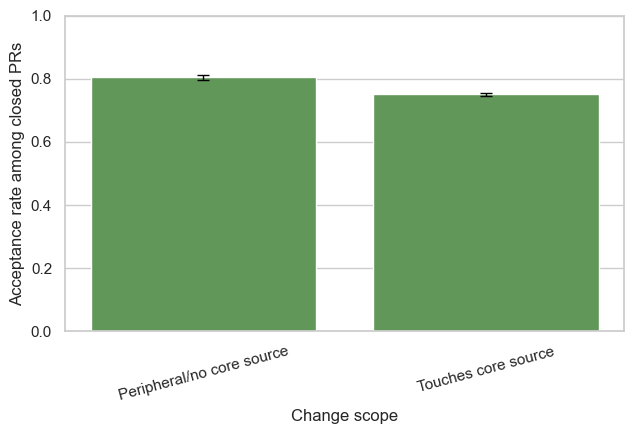

In [19]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
plot_scope = rq4_scope.sort_values('acceptance_rate', ascending=False)
sns.barplot(data=plot_scope, x='change_scope', y='acceptance_rate', color='#59A14F', ax=ax)

scope_yerr_low = plot_scope['acceptance_rate'] - plot_scope['acceptance_ci_low']
scope_yerr_high = plot_scope['acceptance_ci_high'] - plot_scope['acceptance_rate']
ax.errorbar(
    x=range(len(plot_scope)),
    y=plot_scope['acceptance_rate'],
    yerr=[scope_yerr_low, scope_yerr_high],
    fmt='none',
    color='black',
    capsize=4,
    linewidth=1,
)
ax.set_xlabel('Change scope')
ax.set_ylabel('Acceptance rate among closed PRs')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=15)
fig.tight_layout()

rq4_scope_figure_path = FIGURES / 'rq4b_acceptance_by_scope.png'
fig.savefig(rq4_scope_figure_path, dpi=200)
rq4_scope_figure_path

PosixPath('/Users/moutaz/Documents/projects/SW-projects/agent-pr-analyzer/figures/rq4b_acceptance_by_agent_and_scope.png')

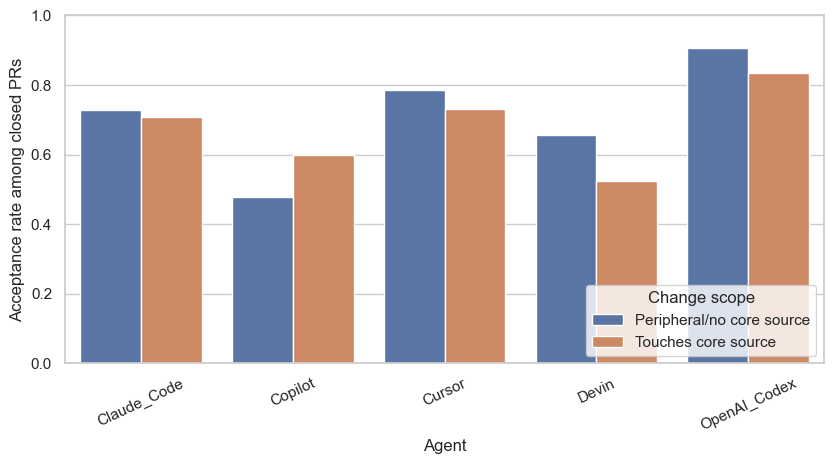

In [20]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
sns.barplot(
    data=rq4_agent_scope,
    x='agent',
    y='acceptance_rate',
    hue='change_scope',
    ax=ax,
)
ax.set_xlabel('Agent')
ax.set_ylabel('Acceptance rate among closed PRs')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=25)
ax.legend(title='Change scope', loc='lower right')
fig.tight_layout()

rq4_agent_figure_path = FIGURES / 'rq4b_acceptance_by_agent_and_scope.png'
fig.savefig(rq4_agent_figure_path, dpi=200)
rq4_agent_figure_path

### RQ4-B Interpretation Draft

Peripheral/no-core PRs have a moderately higher acceptance rate than PRs touching core source code. This is an association, and the pattern can vary by agent and repository context.

## 9. Analysis Complete

The notebook now contains the analyses for RQ1, RQ2, RQ3, and RQ4-B. The remaining coursework work is to turn these results into the report, presentation, README polish, and threats-to-validity discussion.